# Reduced-Form ECL Simulation — Vendor Disagreement Under Three Damage Scenarios

**Purpose:** Illustrate how vendor disagreement in physical damage ratios translates into
materially different portfolio-level Expected Credit Loss (ECL) and IFRS 9 staging outcomes.

**Approach:** Reduced-form transmission model. Rather than sampling from fitted damage distributions,
we apply three deterministic scenarios using the observed CFRF/GARP benchmarking data directly:

| Scenario | Damage ratio used | Interpretation |
|---|---|---|
| Baseline | d = 0 | No flood; all loans Stage 1 |
| Min DR | d = minimum across 13 vendors | Most optimistic vendor |
| Mean DR | d = mean across 13 vendors | Consensus estimate |
| Max DR | d = maximum across 13 vendors | Most pessimistic vendor |

**Transmission chain:**
```
PD_12m(d) = PD_0 × exp(α × d)
LGD(d)    = min(LGD_0 + λ × d, 1)
PD_LT(d)  = 1 − (1 − PD_12m(d))^T
SICR      = PD_LT(d) / PD_LT_baseline > τ  →  Stage 2
ECL       = PD_12m × LGD × EAD  (Stage 1)
          = PD_LT  × LGD × EAD  (Stage 2)
```

In [27]:
# =============================================================================
# PARAMETERS — edit this cell to explore sensitivity
# =============================================================================

# --- Data ---
DATA_PATH = "../../data/raw/cfrf_garp_defended_flood.csv"
RANDOM_SEED = 42

# --- Portfolio draws (reduced-form model) ---
EAD_LOW,  EAD_HIGH  = 0.5,  5.0   # EAD £m, Uniform
PD_MU,    PD_SIGMA  = -5.5, 0.8   # baseline PD_12m, Log-Normal: median ≈ 0.4%
LGD_LOW,  LGD_HIGH  = 0.20, 0.45  # baseline LGD, Uniform
MAT_LOW,  MAT_HIGH  = 5,    25    # loan maturity years, discrete Uniform

# --- Reduced-form transmission ---
ALPHA      = 2.0   # PD sensitivity:  PD_12m(d) = PD_0 × exp(α × d)
LAMBDA_LGD = 0.25  # LGD sensitivity: LGD(d) = LGD_0 + λ × d

# --- IFRS 9 staging ---
TAU = 2.0          # SICR threshold (EBA benchmark: lifetime PD doubles)

# --- Sensitivity grid (Section 4) ---
ALPHA_GRID = [0.5, 1.0, 2.0, 3.0, 5.0]   # α values to sweep
TAU_GRID   = [1.5, 2.0, 2.5, 3.0]         # τ values to sweep

# --- Vendor portfolio simulation (Section 5) ---
N_VENDORS = 5000   # number of hypothetical vendors to simulate

In [28]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

## 1. Data & Portfolio Construction

In [29]:
# Load and clean CFRF/GARP data
df = pd.read_csv(DATA_PATH)
df.rename(columns={"minimim_dr": "minimum_dr"}, inplace=True)  # fix typo in source
df = df.dropna(subset=["property_rank"]).reset_index(drop=True)
df["property_rank"] = df["property_rank"].astype(int)

n = len(df)
print(f"Properties loaded: {n}")
print(f"  Zero-damage (all vendors): {(df['maximum_dr'] == 0).sum()}")
print(f"  Non-zero damage: {(df['maximum_dr'] > 0).sum()}")
print(f"  Damage ratio range — min: [{df['minimum_dr'].min():.3f}, {df['minimum_dr'].max():.3f}]")
print(f"  Damage ratio range — max: [{df['maximum_dr'].min():.3f}, {df['maximum_dr'].max():.3f}]")

Properties loaded: 100
  Zero-damage (all vendors): 20
  Non-zero damage: 80
  Damage ratio range — min: [0.000, 0.250]
  Damage ratio range — max: [0.000, 1.000]


In [30]:
# Build stylised loan portfolio — one loan per CFRF/GARP property
rng = np.random.default_rng(RANDOM_SEED)

# Independent draws from assumed distributions
ead_m        = rng.uniform(EAD_LOW, EAD_HIGH, size=n)
pd_12m_base  = stats.lognorm.rvs(
    s=PD_SIGMA, scale=np.exp(PD_MU), size=n,
    random_state=int(rng.integers(2**31))
)
pd_12m_base  = np.clip(pd_12m_base, 1e-6, 0.9999)
lgd_base     = rng.uniform(LGD_LOW, LGD_HIGH, size=n)
maturity     = rng.integers(MAT_LOW, MAT_HIGH + 1, size=n)
pd_lt_base   = 1.0 - (1.0 - pd_12m_base) ** maturity

portfolio = pd.DataFrame({
    "property_rank": df["property_rank"].values,
    "d_min":         df["minimum_dr"].values,
    "d_mean":        df["mean_dr"].values,
    "d_max":         df["maximum_dr"].values,
    "vendor_spread": (df["maximum_dr"] - df["minimum_dr"]).values,
    "ead_m":         ead_m,
    "pd_12m_base":   pd_12m_base,
    "lgd_base":      lgd_base,
    "maturity":      maturity,
    "pd_lt_base":    pd_lt_base,
})

print("Portfolio summary:")
print(f"  Loans:            {n}")
print(f"  Total EAD:        £{portfolio['ead_m'].sum():.1f}m")
print(f"  Avg EAD:          £{portfolio['ead_m'].mean():.2f}m")
print(f"  Baseline PD₁₂m:   {portfolio['pd_12m_base'].mean()*100:.3f}% (mean)")
print(f"  Baseline LGD:     {portfolio['lgd_base'].mean()*100:.1f}% (mean)")
print(f"  Maturity:         {portfolio['maturity'].mean():.1f}y (mean)")

# Baseline ECL (no flood, d=0)
baseline_ecl_m = portfolio["pd_12m_base"] * portfolio["lgd_base"] * portfolio["ead_m"]
print(f"  Baseline ECL:     £{baseline_ecl_m.sum():.3f}m")

Portfolio summary:
  Loans:            100
  Total EAD:        £269.0m
  Avg EAD:          £2.69m
  Baseline PD₁₂m:   0.549% (mean)
  Baseline LGD:     32.5% (mean)
  Maturity:         15.1y (mean)
  Baseline ECL:     £0.465m


## 2. Apply Damage Scenarios

In [31]:
def apply_scenario(portfolio: pd.DataFrame, d: np.ndarray,
                   alpha: float, lambda_lgd: float, tau: float) -> pd.DataFrame:
    """
    Apply reduced-form credit risk transmission for a given damage ratio vector.

    Parameters
    ----------
    portfolio : DataFrame with pd_12m_base, lgd_base, pd_lt_base, maturity, ead_m
    d         : damage ratio array, shape (n,)
    alpha     : PD sensitivity  — PD_12m(d) = PD_0 × exp(α × d)
    lambda_lgd: LGD sensitivity — LGD(d) = LGD_0 + λ × d, capped at 1
    tau       : SICR threshold  — flag if PD_LT_stressed / PD_LT_base > τ

    Returns
    -------
    DataFrame with stressed quantities, SICR flag, stage, and ECL.
    """
    pd_stressed  = np.clip(portfolio["pd_12m_base"].values * np.exp(alpha * d), 0, 0.9999)
    lgd_stressed = np.minimum(portfolio["lgd_base"].values + lambda_lgd * d, 1.0)
    T            = portfolio["maturity"].values
    pd_lt_str    = 1.0 - (1.0 - pd_stressed) ** T
    sicr_ratio   = pd_lt_str / portfolio["pd_lt_base"].values
    stage        = np.where(sicr_ratio > tau, 2, 1)
    ead          = portfolio["ead_m"].values

    # ECL: 12m PD for Stage 1, lifetime PD for Stage 2
    ecl_m = np.where(
        stage == 2,
        pd_lt_str * lgd_stressed * ead,
        pd_stressed * lgd_stressed * ead,
    )

    return pd.DataFrame({
        "pd_stressed":   pd_stressed,
        "lgd_stressed":  lgd_stressed,
        "pd_lt_str":     pd_lt_str,
        "sicr_ratio":    sicr_ratio,
        "stage":         stage,
        "ecl_m":         ecl_m,
    })

In [32]:
# Run all four scenarios
scenario_specs = {
    "Baseline": np.zeros(n),
    "Min DR":   portfolio["d_min"].values,
    "Mean DR":  portfolio["d_mean"].values,
    "Max DR":   portfolio["d_max"].values,
}

scenario_results = {
    label: apply_scenario(portfolio, d, ALPHA, LAMBDA_LGD, TAU)
    for label, d in scenario_specs.items()
}

## 3. Results

In [33]:
# Portfolio-level summary table
ead_total = portfolio["ead_m"].sum()
rows = []
for label, res in scenario_results.items():
    ecl_tot = res["ecl_m"].sum()
    ecl_s1  = res.loc[res["stage"] == 1, "ecl_m"].sum()
    ecl_s2  = res.loc[res["stage"] == 2, "ecl_m"].sum()
    n_s2    = (res["stage"] == 2).sum()
    rows.append({
        "Scenario":          label,
        "Total ECL (£m)":    round(ecl_tot, 4),
        "Stage 1 ECL (£m)":  round(ecl_s1, 4),
        "Stage 2 ECL (£m)":  round(ecl_s2, 4),
        "Loans in Stage 2":  int(n_s2),
        "ECL/EAD (bps)":     round(ecl_tot / ead_total * 1e4, 2),
    })

summary = pd.DataFrame(rows).set_index("Scenario")
print("Portfolio ECL Summary")
print("=" * 70)
print(summary.to_string())
print()

# ECL uplift relative to baseline
baseline_ecl = summary.loc["Baseline", "Total ECL (£m)"]
for label in ["Min DR", "Mean DR", "Max DR"]:
    uplift = summary.loc[label, "Total ECL (£m)"] - baseline_ecl
    pct    = uplift / baseline_ecl * 100
    print(f"  {label}: +£{uplift:.4f}m ECL vs baseline ({pct:+.1f}%)")

ecl_min_to_max = (
    summary.loc["Max DR", "Total ECL (£m)"] -
    summary.loc["Min DR", "Total ECL (£m)"]
)
print(f"\n  Vendor range (Max − Min): £{ecl_min_to_max:.4f}m in total portfolio ECL")

Portfolio ECL Summary
          Total ECL (£m)  Stage 1 ECL (£m)  Stage 2 ECL (£m)  Loans in Stage 2  ECL/EAD (bps)
Scenario                                                                                     
Baseline          0.4653            0.4653            0.0000                 0          17.30
Min DR            0.4741            0.4741            0.0000                 0          17.62
Mean DR           1.7674            0.6054            1.1620                 7          65.70
Max DR           13.8618            0.4899           13.3719                38         515.26

  Min DR: +£0.0088m ECL vs baseline (+1.9%)
  Mean DR: +£1.3021m ECL vs baseline (+279.8%)
  Max DR: +£13.3965m ECL vs baseline (+2879.1%)

  Vendor range (Max − Min): £13.3877m in total portfolio ECL


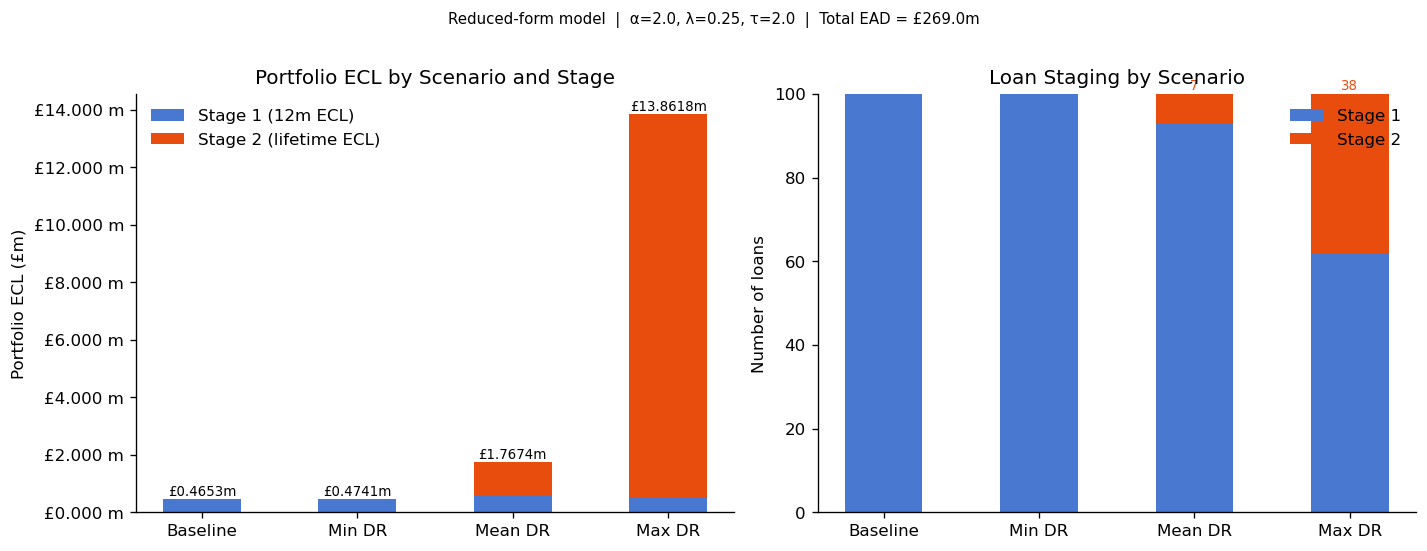

In [34]:
# Figure 1 — Portfolio ECL by scenario and stage; SICR staging overview
labels  = list(scenario_results.keys())
ecl_s1  = [scenario_results[s].loc[scenario_results[s]["stage"]==1, "ecl_m"].sum() for s in labels]
ecl_s2  = [scenario_results[s].loc[scenario_results[s]["stage"]==2, "ecl_m"].sum() for s in labels]
n_s1    = [(scenario_results[s]["stage"]==1).sum() for s in labels]
n_s2    = [(scenario_results[s]["stage"]==2).sum() for s in labels]

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: stacked ECL bar chart
ax = axes[0]
bars1 = ax.bar(x, ecl_s1, label="Stage 1 (12m ECL)", color="#4878CF", width=0.5)
bars2 = ax.bar(x, ecl_s2, bottom=ecl_s1, label="Stage 2 (lifetime ECL)", color="#E84D0E", width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Portfolio ECL (£m)")
ax.set_title("Portfolio ECL by Scenario and Stage")
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("£%.3f m"))
# Annotate total ECL above each bar
for i, (s1, s2) in enumerate(zip(ecl_s1, ecl_s2)):
    ax.text(i, s1 + s2 + 0.0002, f"£{s1+s2:.4f}m", ha="center", va="bottom", fontsize=8)

# Right: loans per stage (stacked bar)
ax2 = axes[1]
ax2.bar(x, n_s1, label="Stage 1", color="#4878CF", width=0.5)
ax2.bar(x, n_s2, bottom=n_s1, label="Stage 2", color="#E84D0E", width=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_ylabel("Number of loans")
ax2.set_title("Loan Staging by Scenario")
ax2.legend(frameon=False)
for i, n2 in enumerate(n_s2):
    if n2 > 0:
        ax2.text(i, n_s1[i] + n2 + 0.3, str(n2), ha="center", va="bottom", fontsize=8, color="#E84D0E")

fig.suptitle(
    f"Reduced-form model  |  α={ALPHA}, λ={LAMBDA_LGD}, τ={TAU}  |  "
    f"Total EAD = £{ead_total:.1f}m",
    fontsize=9, y=1.01
)
plt.tight_layout()
plt.show()

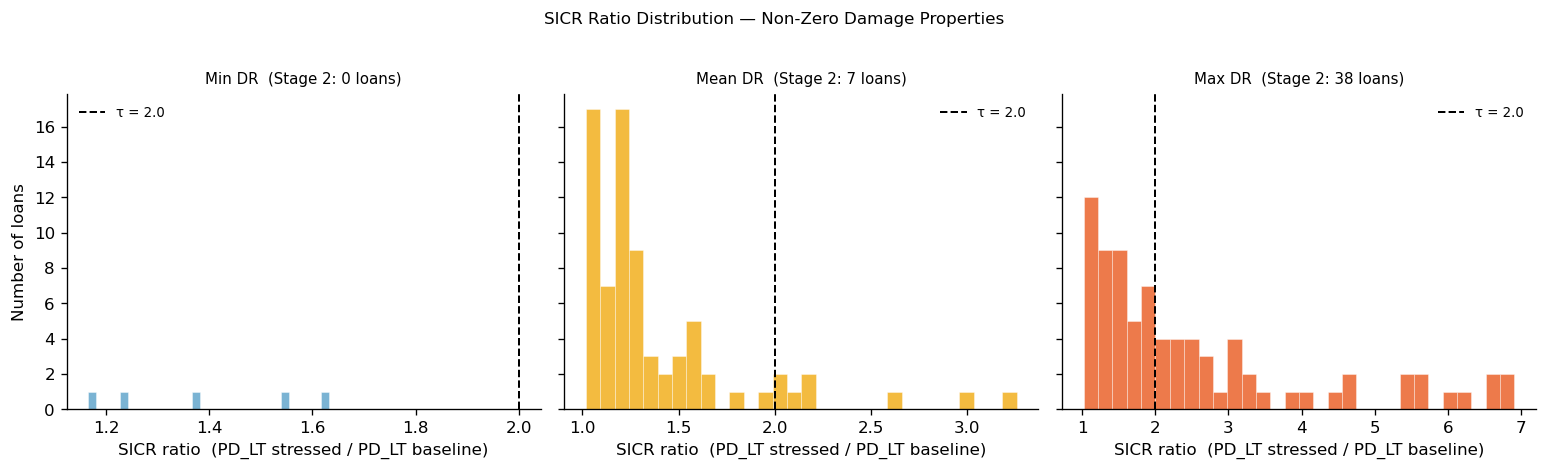

In [35]:
# Figure 2 — SICR ratio distribution across loans (excluding baseline and zero-damage)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True, sharex=False)
plot_scenarios = ["Min DR", "Mean DR", "Max DR"]
colors = ["#4D9AC5", "#F0A500", "#E84D0E"]

for ax, label, col in zip(axes, plot_scenarios, colors):
    res  = scenario_results[label]
    d_sc = scenario_specs[label]
    # Exclude zero-damage properties (no vendor disagreement signal)
    mask = d_sc > 0
    sicr = res.loc[mask, "sicr_ratio"]

    ax.hist(sicr, bins=30, color=col, alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(TAU, color="k", linewidth=1.2, linestyle="--", label=f"τ = {TAU}")
    n_staged = (res.loc[mask, "stage"] == 2).sum()
    ax.set_title(f"{label}  (Stage 2: {n_staged} loans)", fontsize=9)
    ax.set_xlabel("SICR ratio  (PD_LT stressed / PD_LT baseline)")
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel("Number of loans")
fig.suptitle(
    "SICR Ratio Distribution — Non-Zero Damage Properties",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

## 4. Sensitivity Analysis

How sensitive are the results to the key uncertain parameters α (PD amplification)
and τ (SICR threshold)? We sweep both and report total portfolio ECL and
number of Stage 2 loans under the **mean DR scenario** (the consensus estimate).

In [36]:
# Sensitivity grid: α × τ, mean DR scenario
d_mean = portfolio["d_mean"].values

ecl_grid = np.zeros((len(ALPHA_GRID), len(TAU_GRID)))
n_s2_grid = np.zeros((len(ALPHA_GRID), len(TAU_GRID)), dtype=int)

for i, a in enumerate(ALPHA_GRID):
    for j, t in enumerate(TAU_GRID):
        res = apply_scenario(portfolio, d_mean, alpha=a, lambda_lgd=LAMBDA_LGD, tau=t)
        ecl_grid[i, j]  = res["ecl_m"].sum()
        n_s2_grid[i, j] = (res["stage"] == 2).sum()

# Display as DataFrames
idx = [f"α = {a}" for a in ALPHA_GRID]
col = [f"τ = {t}" for t in TAU_GRID]

print("Total portfolio ECL (£m) — Mean DR scenario")
print(pd.DataFrame(ecl_grid, index=idx, columns=col).round(4).to_string())
print()
print("Loans in Stage 2 — Mean DR scenario")
print(pd.DataFrame(n_s2_grid, index=idx, columns=col).to_string())

Total portfolio ECL (£m) — Mean DR scenario
         τ = 1.5  τ = 2.0  τ = 2.5  τ = 3.0
α = 0.5   0.5448   0.5448   0.5448   0.5448
α = 1.0   1.0097   0.5853   0.5853   0.5853
α = 2.0   3.5605   1.7674   1.4203   1.3383
α = 3.0   5.8944   3.2811   3.0803   2.3387
α = 5.0  12.4512   9.7015   8.5829   7.3507

Loans in Stage 2 — Mean DR scenario
         τ = 1.5  τ = 2.0  τ = 2.5  τ = 3.0
α = 0.5        0        0        0        0
α = 1.0        3        0        0        0
α = 2.0       17        7        3        2
α = 3.0       26       12        9        6
α = 5.0       48       24       19       16


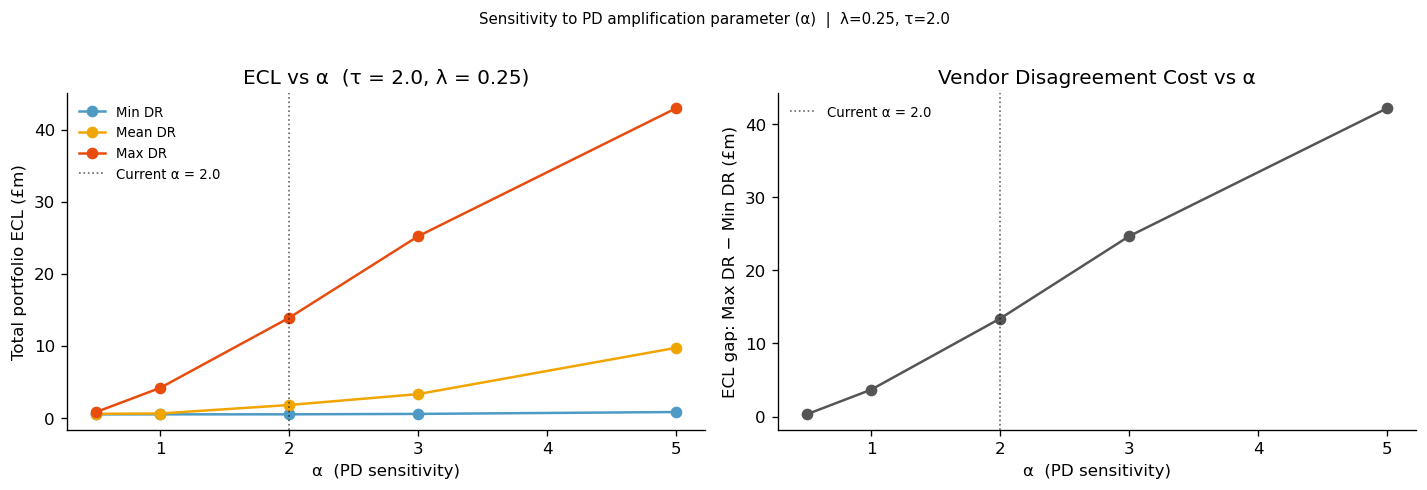

In [37]:
# Figure 3 — Sensitivity: ECL vs α for each damage scenario (τ fixed at TAU)
d_vectors = {
    "Min DR":  portfolio["d_min"].values,
    "Mean DR": portfolio["d_mean"].values,
    "Max DR":  portfolio["d_max"].values,
}
scenario_colors = {"Min DR": "#4D9AC5", "Mean DR": "#F0A500", "Max DR": "#E84D0E"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: ECL vs α
ax = axes[0]
for label, d_vec in d_vectors.items():
    ecl_vals = [
        apply_scenario(portfolio, d_vec, alpha=a, lambda_lgd=LAMBDA_LGD, tau=TAU)["ecl_m"].sum()
        for a in ALPHA_GRID
    ]
    ax.plot(ALPHA_GRID, ecl_vals, marker="o", label=label, color=scenario_colors[label])

# Mark current ALPHA
ax.axvline(ALPHA, color="k", linewidth=1, linestyle=":", alpha=0.6, label=f"Current α = {ALPHA}")
ax.set_xlabel("α  (PD sensitivity)")
ax.set_ylabel("Total portfolio ECL (£m)")
ax.set_title(f"ECL vs α  (τ = {TAU}, λ = {LAMBDA_LGD})")
ax.legend(frameon=False, fontsize=8)

# Right: vendor range (Max ECL − Min ECL) vs α — measures the cost of vendor disagreement
ax2 = axes[1]
ecl_max_by_alpha = [
    apply_scenario(portfolio, d_vectors["Max DR"], alpha=a, lambda_lgd=LAMBDA_LGD, tau=TAU)["ecl_m"].sum()
    for a in ALPHA_GRID
]
ecl_min_by_alpha = [
    apply_scenario(portfolio, d_vectors["Min DR"], alpha=a, lambda_lgd=LAMBDA_LGD, tau=TAU)["ecl_m"].sum()
    for a in ALPHA_GRID
]
vendor_gap = np.array(ecl_max_by_alpha) - np.array(ecl_min_by_alpha)

ax2.plot(ALPHA_GRID, vendor_gap, marker="o", color="#555555")
ax2.axvline(ALPHA, color="k", linewidth=1, linestyle=":", alpha=0.6, label=f"Current α = {ALPHA}")
ax2.set_xlabel("α  (PD sensitivity)")
ax2.set_ylabel("ECL gap: Max DR − Min DR (£m)")
ax2.set_title("Vendor Disagreement Cost vs α")
ax2.legend(frameon=False, fontsize=8)

fig.suptitle(
    f"Sensitivity to PD amplification parameter (α)  |  λ={LAMBDA_LGD}, τ={TAU}",
    fontsize=9, y=1.01
)
plt.tight_layout()
plt.show()

## 5. Simulated Vendor Portfolios

The §3 scenarios (min/mean/max DR) are useful benchmarks but unrealistic: the "max vendor"
is a fictional entity that is simultaneously the most pessimistic about *every single property*.
No real vendor behaves like that — disagreement is distributed unevenly across locations.

**More realistic framing.** In practice, an FI consults one (or occasionally two) vendors
and applies that vendor's estimates across the whole portfolio. Different FIs — or the same FI
at different times — may use different vendors, and each vendor independently forms their own
view of each property.

**Simulation approach:**
1. For each simulated vendor, draw **one damage estimate per property** independently from
   that property's triangular uncertainty distribution. This produces a full 100-property
   "vendor portfolio" — vendor A might report high damage for property 3 and low for
   property 17, just as real vendors disagree in different locations.
2. Compute portfolio-level ECL for that vendor's estimates.
3. Repeat for N simulated vendors to obtain the *distribution* of ECL outcomes across
   plausible vendor choices.
4. For pairs of vendors, compute ECL_A − ECL_B — the direct financial cost of choosing
   one vendor over another.

**Key assumption:** the triangular distribution is calibrated to the *observed* spread
across the 13 CFRF/GARP vendors. Simulated vendors therefore inherit that level of
cross-vendor disagreement.

In [38]:
# Triangular distribution parameters per property (derived from CFRF/GARP data)
tri_a = df["minimum_dr"].values.astype(float)   # lower bound
tri_b = df["maximum_dr"].values.astype(float)   # upper bound
tri_c = np.clip(                                 # mode = 3*mean - a - b, clamped to [a, b]
    3.0 * df["mean_dr"].values - tri_a - tri_b,
    tri_a, tri_b
)

# Flag degenerate properties (all vendors agree, or all-zero)
is_point_mass = (tri_b == tri_a)  # includes zero-damage and any property where min==max

print(f"Properties with triangular uncertainty: {(~is_point_mass).sum()}")
print(f"  Point masses (min == max, incl. zero-damage): {is_point_mass.sum()}")
print(f"  Damage range across all properties: [{tri_a.min():.3f}, {tri_b.max():.3f}]")

Properties with triangular uncertainty: 80
  Point masses (min == max, incl. zero-damage): 20
  Damage range across all properties: [0.000, 1.000]


In [39]:
def simulate_vendor_portfolios(portfolio, tri_a, tri_b, tri_c,
                                n_vendors, alpha, lambda_lgd, tau, rng):
    """
    Simulate n_vendors hypothetical vendor portfolios.

    Each vendor independently draws one damage estimate per property from that
    property's triangular distribution — capturing the realistic scenario where
    vendors agree on some properties and disagree on others.

    Parameters
    ----------
    portfolio : DataFrame with pd_12m_base, lgd_base, pd_lt_base, maturity, ead_m
    tri_a/b/c : triangular distribution parameters per property (arrays, length n_props)
    n_vendors : number of hypothetical vendors to simulate
    alpha, lambda_lgd, tau : transmission and staging parameters

    Returns
    -------
    ecl_portfolio : ndarray (n_vendors,)  — total portfolio ECL per vendor
    n_s2          : ndarray (n_vendors,)  — loans in Stage 2 per vendor
    d_matrix      : ndarray (n_props, n_vendors)  — damage estimates per property per vendor
    """
    n_props = len(portfolio)

    # One draw per property per vendor: shape (n_props, n_vendors)
    u = rng.uniform(size=(n_props, n_vendors))
    d_matrix = np.clip(
        triangular_inv_cdf(u, tri_a[:, None], tri_c[:, None], tri_b[:, None]),
        0.0, 1.0
    )

    # Vectorised ECL computation across all vendors simultaneously
    pd0     = portfolio["pd_12m_base"].values[:, None]   # (n_props, 1) → broadcasts
    lgd0    = portfolio["lgd_base"].values[:, None]
    T       = portfolio["maturity"].values[:, None]
    ead     = portfolio["ead_m"].values[:, None]
    pd_lt_b = portfolio["pd_lt_base"].values[:, None]

    pd_str    = np.clip(pd0 * np.exp(alpha * d_matrix), 0.0, 0.9999)
    lgd_str   = np.minimum(lgd0 + lambda_lgd * d_matrix, 1.0)
    pd_lt_str = 1.0 - (1.0 - pd_str) ** T
    stage2    = (pd_lt_str / pd_lt_b) > tau

    ecl = np.where(stage2, pd_lt_str * lgd_str * ead,
                           pd_str    * lgd_str * ead)

    return ecl.sum(axis=0), stage2.sum(axis=0), d_matrix

In [40]:
# Simulate N_VENDORS hypothetical vendor portfolios
sim_rng = np.random.default_rng(RANDOM_SEED + 100)

ecl_vendors, n_s2_vendors, d_matrix = simulate_vendor_portfolios(
    portfolio, tri_a, tri_b, tri_c,
    n_vendors=N_VENDORS,
    alpha=ALPHA, lambda_lgd=LAMBDA_LGD, tau=TAU,
    rng=sim_rng,
)

# Pairwise ECL gap: split the vendor pool in half and compare A vs B
# (each pair represents two FIs that independently chose different vendors)
half = N_VENDORS // 2
ecl_gap_pairwise = ecl_vendors[:half] - ecl_vendors[half:]   # signed: A minus B

# Summary
print(f"Distribution of portfolio ECL across {N_VENDORS} simulated vendors")
print(f"  Mean:   £{ecl_vendors.mean():.3f}m")
print(f"  Median: £{np.median(ecl_vendors):.3f}m")
print(f"  Std:    £{ecl_vendors.std():.3f}m")
print(f"  5th pct:  £{np.percentile(ecl_vendors,  5):.3f}m")
print(f"  95th pct: £{np.percentile(ecl_vendors, 95):.3f}m")
print(f"  P(ECL > £5m): {(ecl_vendors > 5).mean()*100:.1f}%")
print()
print(f"Pairwise ECL gap (vendor A minus vendor B), {half} pairs")
print(f"  Median absolute gap: £{np.abs(ecl_gap_pairwise).median() if hasattr(ecl_gap_pairwise, 'median') else np.median(np.abs(ecl_gap_pairwise)):.3f}m")
print(f"  90th pct abs gap:    £{np.percentile(np.abs(ecl_gap_pairwise), 90):.3f}m")
print(f"  P(|gap| > £1m): {(np.abs(ecl_gap_pairwise) > 1).mean()*100:.1f}%")
print(f"  P(|gap| > £5m): {(np.abs(ecl_gap_pairwise) > 5).mean()*100:.1f}%")
print()
print(f"Stage 2 loan count across vendors")
print(f"  Mean:   {n_s2_vendors.mean():.1f} loans")
print(f"  Range:  [{n_s2_vendors.min()}, {n_s2_vendors.max()}] loans")

# Reference values from §3
ecl_mean_dr  = scenario_results["Mean DR"]["ecl_m"].sum()
ecl_min_dr   = scenario_results["Min DR"]["ecl_m"].sum()
ecl_max_dr   = scenario_results["Max DR"]["ecl_m"].sum()
print(f"\n§3 reference (deterministic):  Min DR=£{ecl_min_dr:.3f}m  "
      f"Mean DR=£{ecl_mean_dr:.3f}m  Max DR=£{ecl_max_dr:.3f}m")

Distribution of portfolio ECL across 5000 simulated vendors
  Mean:   £3.210m
  Median: £3.113m
  Std:    £0.885m
  5th pct:  £1.915m
  95th pct: £4.810m
  P(ECL > £5m): 3.5%

Pairwise ECL gap (vendor A minus vendor B), 2500 pairs
  Median absolute gap: £0.858m
  90th pct abs gap:    £2.079m
  P(|gap| > £1m): 43.0%
  P(|gap| > £5m): 0.0%

Stage 2 loan count across vendors
  Mean:   10.2 loans
  Range:  [3, 19] loans

§3 reference (deterministic):  Min DR=£0.474m  Mean DR=£1.767m  Max DR=£13.862m


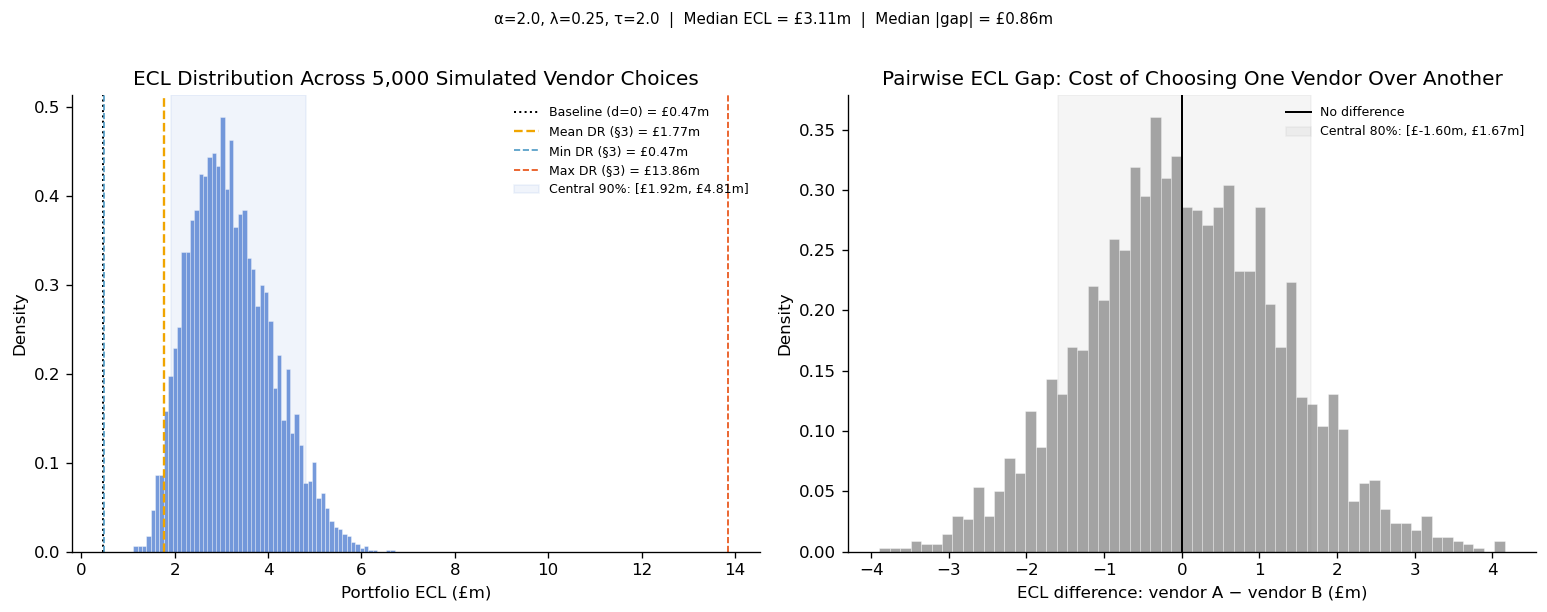

In [41]:
# Figure 4 — Vendor portfolio simulation results
#
# Left:  Distribution of portfolio ECL across N simulated vendors.
#        Each bar = one plausible vendor an FI might use. Reference lines show
#        the §3 deterministic scenarios and the baseline.
#
# Right: Distribution of the pairwise ECL gap (ECL_A − ECL_B) for randomly
#        matched vendor pairs — the direct financial cost of vendor selection.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: ECL distribution across vendors ────────────────────────────────────
ax = axes[0]
ax.hist(ecl_vendors, bins=60, color="#4878CF", alpha=0.75,
        edgecolor="white", linewidth=0.3, density=True)

# Reference lines from §3
baseline_ecl_val = scenario_results["Baseline"]["ecl_m"].sum()
ax.axvline(baseline_ecl_val, color="black",  linewidth=1.2, linestyle=":",
           label=f"Baseline (d=0) = £{baseline_ecl_val:.2f}m")
ax.axvline(ecl_mean_dr,      color="#F0A500", linewidth=1.4, linestyle="--",
           label=f"Mean DR (§3) = £{ecl_mean_dr:.2f}m")
ax.axvline(ecl_min_dr,       color="#4D9AC5", linewidth=1.0, linestyle="--",
           label=f"Min DR (§3) = £{ecl_min_dr:.2f}m")
ax.axvline(ecl_max_dr,       color="#E84D0E", linewidth=1.0, linestyle="--",
           label=f"Max DR (§3) = £{ecl_max_dr:.2f}m")

# Shade central 90% interval
p5, p95 = np.percentile(ecl_vendors, 5), np.percentile(ecl_vendors, 95)
ax.axvspan(p5, p95, alpha=0.08, color="#4878CF",
           label=f"Central 90%: [£{p5:.2f}m, £{p95:.2f}m]")

ax.set_xlabel("Portfolio ECL (£m)")
ax.set_ylabel("Density")
ax.set_title(f"ECL Distribution Across {N_VENDORS:,} Simulated Vendor Choices")
ax.legend(frameon=False, fontsize=7.5)

# ── Right: Pairwise ECL gap ──────────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(ecl_gap_pairwise, bins=60, color="#888888", alpha=0.75,
         edgecolor="white", linewidth=0.3, density=True)
ax2.axvline(0, color="black", linewidth=1.2, linestyle="-", label="No difference")

p10_gap = np.percentile(ecl_gap_pairwise, 10)
p90_gap = np.percentile(ecl_gap_pairwise, 90)
ax2.axvspan(p10_gap, p90_gap, alpha=0.08, color="#888888",
            label=f"Central 80%: [£{p10_gap:.2f}m, £{p90_gap:.2f}m]")

ax2.set_xlabel("ECL difference: vendor A − vendor B (£m)")
ax2.set_ylabel("Density")
ax2.set_title("Pairwise ECL Gap: Cost of Choosing One Vendor Over Another")
ax2.legend(frameon=False, fontsize=7.5)

fig.suptitle(
    f"α={ALPHA}, λ={LAMBDA_LGD}, τ={TAU}  |  "
    f"Median ECL = £{np.median(ecl_vendors):.2f}m  |  "
    f"Median |gap| = £{np.median(np.abs(ecl_gap_pairwise)):.2f}m",
    fontsize=9, y=1.01,
)
plt.tight_layout()
plt.show()